# MODEL BUILDING

Including:

- Feature Engineering
- Feature Selection
- Model Iterations

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

sns.set_theme(style="whitegrid", context="notebook")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import joblib
import os

In [12]:
df = pd.read_csv('../datasets/cleaned_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   year                        869319 non-null  int64  
 1   age_group                   869319 non-null  str    
 2   age                         869319 non-null  float64
 3   sex                         869319 non-null  str    
 4   race                        869319 non-null  str    
 5   weight                      869319 non-null  float64
 6   height                      869319 non-null  float64
 7   bmi                         869319 non-null  float64
 8   marital_status              869319 non-null  str    
 9   education_level             869319 non-null  str    
 10  education                   869319 non-null  float64
 11  employment_status           869319 non-null  str    
 12  income_level                869319 non-null  str    
 13  income                   

In [3]:
df.columns

Index(['year', 'age_group', 'age', 'sex', 'race', 'weight', 'height', 'bmi',
       'marital_status', 'education_level', 'education', 'employment_status',
       'income_level', 'income', 'general_health', 'gen_health',
       'physical_health_days', 'mental_health_days', 'exercise',
       'smoked_100_cigarettes', 'drinks_alcohol', 'high_bp', 'had_stroke',
       'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier',
       'last_checkup', 'l_checkup', 'has_personal_doctor', 'diabetes'],
      dtype='str')

In [11]:
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,2.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,4.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,2.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,4.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


### Feature Selection

To drop:
- year
- age group
- race (won't be relevant for this model)
- weight and height (multicolinearity with bmi, which is a derivative of both)
- education_level
- income level
- general health
- last_checkup

Recode general health, so that: Excellent is 5, and Poor is 1

In [12]:
df.general_health.value_counts()

general_health
Very Good    303836
Good         274836
Excellent    144028
Fair         110367
Poor          36252
Name: count, dtype: int64

In [13]:
df.gen_health.value_counts()

gen_health
2.0    303836
3.0    274836
1.0    144028
4.0    110367
5.0     36252
Name: count, dtype: int64

In [ ]:
df.gen_health = 6 - df.gen_health
df.head()

,year,age_group,age,sex,race,weight,height,bmi,marital_status,education_level,education,employment_status,income_level,income,general_health,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,last_checkup,l_checkup,has_personal_doctor,diabetes
0,2019,40 - 44,5.0,Female,White,220.0,66.0,35.51,Never married,Some college (1-3 years) or Technical school,5.0,A homemaker,"<$10,000",1.0,Very Good,4.0,0.0,30.0,False,True,False,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Non-diabetic
1,2019,60 - 64,9.0,Male,White,150.0,66.0,24.21,Divorced,Some college (1-3 years) or Technical school,5.0,Unable to work,"<$10,000",1.0,Fair,2.0,3.0,12.0,True,True,False,Yes,False,False,False,False,<1 year,1.0,No,Non-diabetic
2,2019,45 - 49,6.0,Female,White,148.0,61.0,27.96,Divorced,High school graduate (12 or GED),4.0,Employed for wages,"<$10,000",1.0,Good,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,<1 year,1.0,"Yes, only one",Diabetic
3,2019,45 - 49,6.0,Male,White,220.0,71.0,30.68,Married,High school graduate (12 or GED),4.0,Employed for wages,"$75,000 - <$100,000",8.0,Very Good,4.0,0.0,0.0,True,True,False,No,False,False,False,False,<1 year,1.0,No,Non-diabetic
4,2019,65 - 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,High school graduate (12 or GED),4.0,Retired,"$15,000 - <$20,000",3.0,Fair,2.0,30.0,0.0,False,True,False,Yes,True,False,False,False,<1 year,1.0,"Yes, only one",Diabetic


In [ ]:
df.gen_health = 6 - df.gen_health
df.head()

to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
           'general_health', 'last_checkup']

df.drop(columns=to_drop, inplace=True)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  bool   
 12  drinks_alcohol              869319 non-null  bool   
 13  high_bp                  

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,True,False,Yes,False,False,False,False,1.0,"Yes, only one",Non-diabetic
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,True,False,Yes,False,False,False,False,1.0,No,Non-diabetic
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,True,True,Yes,False,False,False,False,1.0,"Yes, only one",Diabetic
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,True,False,No,False,False,False,False,1.0,No,Non-diabetic
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,True,False,Yes,True,False,False,False,1.0,"Yes, only one",Diabetic


Change all True/False and Yes/No's to zero's and one's

In [18]:
df.high_bp.value_counts()

high_bp
No            506765
Yes           353556
Borderline      8998
Name: count, dtype: int64

In [26]:
# compiled preprocessing
def wrangle(filepath="../datasets/cleand_data.csv"):
    # read cleaned data
    df = pd.read_csv(filepath)

    # invert direction of general health so that higher values mean better health
    df.gen_health = 6 - df.gen_health

    # drop redundant and low cardinality features
    to_drop = ['year', 'age_group', 'race', 'weight', 'height', 'education_level', 'income_level',
            'general_health', 'last_checkup']
    df.drop(columns=to_drop, inplace=True)

    # convert True/False columns (boolean) to integers
    t_f_cols = ['smoked_100_cigarettes', 'drinks_alcohol', 'had_stroke', 'had_heart_attack', 'had_coronary_heart_disease', 'cost_barrier']
    for col in t_f_cols:
        df[col] = df[col].astype('int8')

    return df

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 869319 entries, 0 to 869318
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         869319 non-null  float64
 1   sex                         869319 non-null  str    
 2   bmi                         869319 non-null  float64
 3   marital_status              869319 non-null  str    
 4   education                   869319 non-null  float64
 5   employment_status           869319 non-null  str    
 6   income                      869319 non-null  float64
 7   gen_health                  869319 non-null  float64
 8   physical_health_days        869319 non-null  float64
 9   mental_health_days          869319 non-null  float64
 10  exercise                    869319 non-null  bool   
 11  smoked_100_cigarettes       869319 non-null  int8   
 12  drinks_alcohol              869319 non-null  int8   
 13  high_bp                  

In [45]:
df.head()

,age,sex,bmi,marital_status,education,employment_status,income,gen_health,physical_health_days,mental_health_days,exercise,smoked_100_cigarettes,drinks_alcohol,high_bp,had_stroke,had_heart_attack,had_coronary_heart_disease,cost_barrier,l_checkup,has_personal_doctor,diabetes
0,5.0,Female,35.51,Never married,5.0,A homemaker,1.0,4.0,0.0,30.0,False,1,0,Yes,0,0,0,0,1.0,"Yes, only one",Non-diabetic
1,9.0,Male,24.21,Divorced,5.0,Unable to work,1.0,2.0,3.0,12.0,True,1,0,Yes,0,0,0,0,1.0,No,Non-diabetic
2,6.0,Female,27.96,Divorced,4.0,Employed for wages,1.0,3.0,0.0,10.0,True,1,1,Yes,0,0,0,0,1.0,"Yes, only one",Diabetic
3,6.0,Male,30.68,Married,4.0,Employed for wages,8.0,4.0,0.0,0.0,True,1,0,No,0,0,0,0,1.0,No,Non-diabetic
4,10.0,Male,37.33,Widowed,4.0,Retired,3.0,2.0,30.0,0.0,False,1,0,Yes,1,0,0,0,1.0,"Yes, only one",Diabetic


In [48]:
df[['had_heart_attack', 'had_coronary_heart_disease']].corr()

,had_heart_attack,had_coronary_heart_disease
had_heart_attack,1.000000,0.448444
had_coronary_heart_disease,0.448444,1.000000


<Axes: xlabel='high_bp', ylabel='count'>

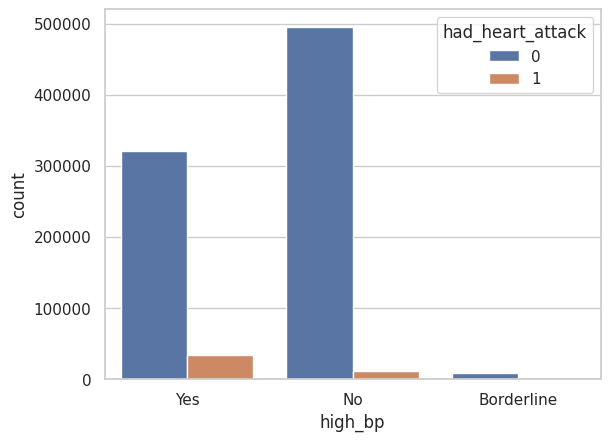

In [ ]:
sns.histplot(data=df, x='high_bp', hue='had_heart_attack')

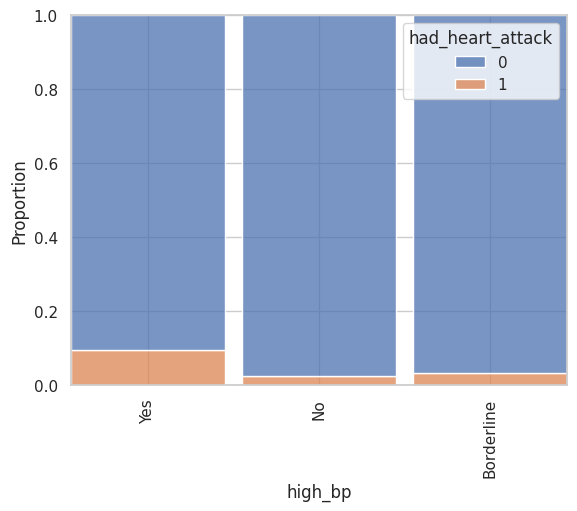

In [50]:
sns.histplot(data=df, x='high_bp', hue='had_heart_attack', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

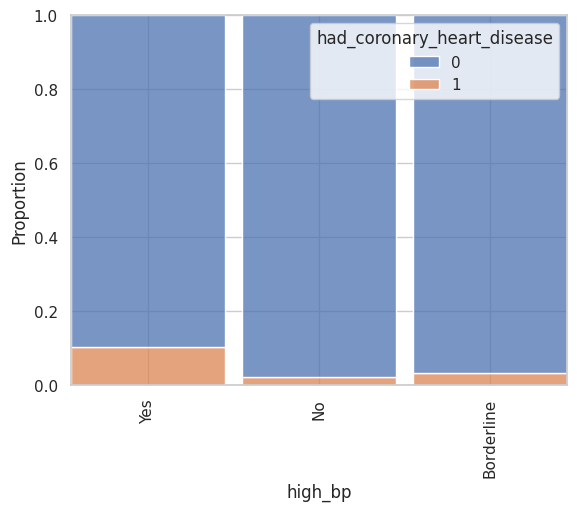

In [52]:
sns.histplot(data=df, x='high_bp', hue='had_coronary_heart_disease', multiple='fill', stat='proportion', shrink=0.9)
plt.xticks(rotation=90);

### Random Guess

In [54]:
df.diabetes.value_counts(normalize=True)

diabetes
Non-diabetic    0.844349
Diabetic        0.133089
Pre-diabetic    0.022561
Name: proportion, dtype: float64

### Split Data

In [17]:
df_1 = df.copy()

In [18]:
target = 'diabetes'

y = df_1[target]
X = df_1.drop(columns=[target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

In [20]:
print(f"Training...\nFeatures:  {len(X_train)}\tTarget:  {len(y_train)}")
print(f"Testing...\nFeatures:  {len(X_test)}\tTarget:  {len(y_test)}")

Training...
Features:  825853	Target:  825853
Testing...
Features:  43466	Target:  43466


In [21]:
y_train.value_counts(normalize=True)

diabetes
Non-diabetic    0.844350
Diabetic        0.133089
Pre-diabetic    0.022561
Name: proportion, dtype: float64

In [22]:
y_test.value_counts(normalize=True)

diabetes
Non-diabetic    0.844338
Diabetic        0.133093
Pre-diabetic    0.022569
Name: proportion, dtype: float64

### Baseline Model with Logistic Regression

In [ ]:
def detect_columns(features):
    num_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = features.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    return num_cols, cat_cols



In [25]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('ohe', OneHotEncoder()),
    ('lr', LogisticRegression(random_state=42))
])


logreg.fit(X_train, y_train)

lr_pred = logreg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, lr_pred)}")
acc = accuracy_score(y_test, lr_pred)



ValueError: could not convert string to float: 'Female'